### Task - 1:Importing necessary libraries

### Importing necessary libraries

In [19]:
import os
import random
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.models import load_model
from tensorflow.keras import models, layers, Input
from sklearn.metrics import classification_report
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.preprocessing.image import load_img, img_to_array

In [51]:
# Define dataset paths
test_dir = "C:/Users/A C E R/Desktop/Artificial Intelligence and Machine Learning/Week5/FruitinAmazon/test"
train_dir = "C:/Users/A C E R/Desktop/Artificial Intelligence and Machine Learning/Week5/FruitinAmazon/train"

### Task 1: Data Understanding and Visualization

Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


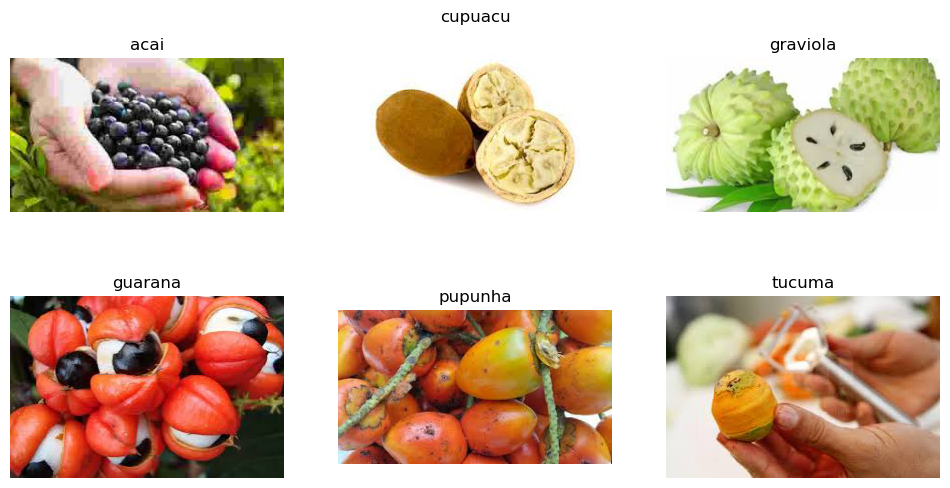

In [53]:
class_names = os.listdir(train_dir)
print(f"Classes: {class_names}")

def visualize_images(train_dir, class_names):
    fig, axes = plt.subplots(2, len(class_names) // 2, figsize=(12, 6))
    axes = axes.flatten()
    for i, class_name in enumerate(class_names):
        class_path = os.path.join(train_dir, class_name)
        img_name = random.choice(os.listdir(class_path))
        img_path = os.path.join(class_path, img_name)
        img = load_img(img_path)
        axes[i].imshow(img)
        axes[i].set_title(class_name)
        axes[i].axis("off")
    plt.show()

visualize_images(train_dir, class_names)

In [55]:
# List to store corrupted image paths
corrupted_images = []

# Iterate through each class subdirectory
for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)
    
    if os.path.isdir(class_path):  # Ensure it's a directory
        for image_file in os.listdir(class_path):
            image_path = os.path.join(class_path, image_file)
            try:
                with Image.open(image_path) as img:
                    img.verify()  # Verify if the image can be opened
            except (IOError, SyntaxError):
                corrupted_images.append(image_path)
                os.remove(image_path)
                print(f"Removed corrupted image: {image_path}")

# Print summary
if not corrupted_images:
    print("No Corrupted Images Found.")

No Corrupted Images Found.


### Task 2: Loading and Preprocessing Image Data in keras

In [57]:
# Define image size and batch size
img_height = 128
img_width = 128
batch_size = 16
validation_split = 0.2 

# Normalize pixel values to [0, 1]
rescale = tf.keras.layers.Rescaling(1./255)


train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

# Apply the normalization (Rescaling) to the dataset
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# Create validation dataset with normalization
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
).map(lambda x, y: (rescale(x), y)) #Normalizing validation dataset

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


### Task 3 - Create a CNN Model

In [59]:
def create_cnn_model(input_shape, num_classes):
    model = models.Sequential([
        # Convolutional Layer 1
        layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=input_shape),

        #Pooling Layer 1
        layers.MaxPooling2D((2, 2)),

        # Convolutional Layer 2
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),

        #Pooling Layer 2
        layers.MaxPooling2D((2, 2)),

        # Flatten Layer
        layers.Flatten(),

        # Fully Connected Network Architecture
        layers.Dense(64, activation='relu'), 
        layers.Dense(128, activation='relu'), 

        # Output Layer
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model

# Ensure input shape matches dataset
input_shape = (128, 128, 3) 
num_classes = 6

model = create_cnn_model(input_shape, num_classes)

# Print model summary to verify shapes
model.summary()


C:\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │     4,194,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,222,854 (16.11 MB)

 Trainable params: 4,222,854 (16.11 MB)

 Non-trainable params: 0 (0.00 B)

In [61]:
# Callbacks to avoid overfitting and save the best model
checkpoint_cb = ModelCheckpoint("best_model.keras", save_best_only=True, monitor='val_loss', mode='min')
early_stopping_cb = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

### Task 4: Compile the Model

In [63]:
model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

### Task 4: Train the Model

In [65]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250, 
    batch_size=batch_size, 
    callbacks=[checkpoint_cb, early_stopping_cb]
)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 212ms/step - accuracy: 0.1105 - loss: 2.0463 - val_accuracy: 0.3333 - val_loss: 1.6052
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 141ms/step - accuracy: 0.3594 - loss: 1.6383 - val_accuracy: 0.2778 - val_loss: 1.5161
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 143ms/step - accuracy: 0.3996 - loss: 1.4476 - val_accuracy: 0.7222 - val_loss: 1.1766
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 141ms/step - accuracy: 0.6762 - loss: 1.0711 - val_accuracy: 0.9444 - val_loss: 0.6680
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - accuracy: 0.9100 - loss: 0.6132 - val_accuracy: 0.7778 - val_loss: 0.9693
Epoch 6/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 157ms/step - accuracy: 0.9497 - loss: 0.3705 - val_accuracy: 0.8889 - val_loss: 0.3875
Epoch 7/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 137ms/step - accuracy: 0.9161 - loss: 0.2329 - val_accuracy: 0.8889 - val_loss: 0.3875
Epoch 8/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 153ms/step - accuracy: 0.9737 - loss: 0.0936 - val_accuracy: 0.8333 - va

### Task 5: Evaluate the Model

In [69]:
# prepare test dataset (similar to train/val)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,  
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False  # No need to shuffle for evaluation
)

# Apply the same normalization used during training
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

#Evaluate the model
print("\nEvaluating on test set...")
test_loss, test_acc = model.evaluate(val_ds)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

Found 30 files belonging to 6 classes.

Evaluating on test set...
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8843 - loss: 0.1631
Test Accuracy: 0.8889
Test Loss: 0.1720


### Task 6: Save and Load the Model

In [73]:
#save model
model.save('my_model.keras')  
print("Model saved in .keras formats")

# Load the saved model 
loaded_model = load_model('my_model.keras') 
print("\nModel loaded successfully")

# Re-evaluate on test set
print("\nRe-evaluating loaded model...")
test_loss, test_accuracy = loaded_model.evaluate(val_ds, verbose=1)

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

Model saved in .keras formats

Model loaded successfully

Re-evaluating loaded model...
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8843 - loss: 0.1631 
Test Accuracy: 0.8889
Test Loss: 0.1720


### Task 7: Predictions and Classification Report

In [75]:
# Get true labels and predictions
y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)  # Convert probabilities to class labels

# Generate classification report
report = classification_report(y_true, y_pred, target_names=class_names)
print("Classification Report:\n", report)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
Classification Report:
               precision    recall  f1-score   support

        acai       0.62      1.00      0.77         5
     cupuacu       0.75      0.60      0.67         5
    graviola       0.62      1.00      0.77         5
     guarana       0.80      0.80      0.80         5
     pupunha       1.00      0.60      0.75         5
      tucuma       1.00      0.40      0.57         5

    accuracy                           0.73        30
   macro avg       0.80      0.73      0.72        30
weighted avg       0.80      0.73      0.72        30



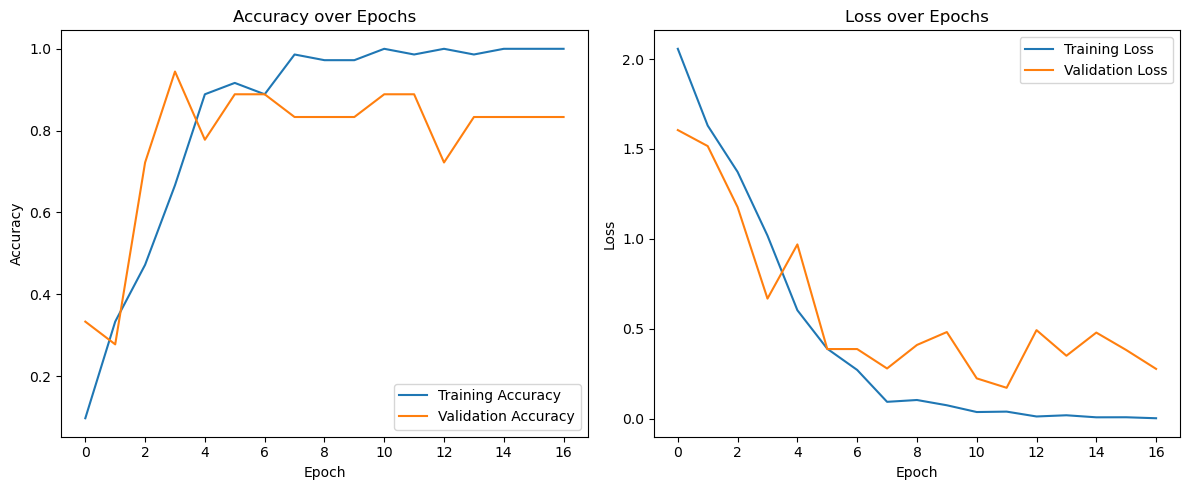

In [77]:
# Plot training & validation accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy over Epochs')

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss over Epochs')

plt.tight_layout()
plt.show()